In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.utils import image_dataset_from_directory 

Data Preparation

In [25]:
training_set=image_dataset_from_directory(
    "./train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
)  

Found 76515 files belonging to 4 classes.


In [26]:
validation_set=image_dataset_from_directory(
    "./val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
)  

Found 21861 files belonging to 4 classes.


In [27]:
input_shape=(224,224,3)

In [ ]:
'''mobilenet=tf.keras.applications.MobileNetV3Large(
    input_shape=input_shape,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
)#'''

In [28]:
mobilenet = tf.keras.applications.MobileNetV3Small(
    input_shape=input_shape,
    alpha=1.0,
    minimalistic=False,
    include_top=False,          # exclude ImageNet classifier
    weights="imagenet",
    pooling="avg",              # GlobalAveragePooling2D
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True
)

In [29]:
for layer in mobilenet.layers:
    layer.trainable = False

In [30]:
model=tf.keras.models.Sequential()

In [31]:
model.add(tf.keras.Input(shape=input_shape))

In [32]:
model.add(mobilenet)

In [33]:
model.add(tf.keras.layers.Dense(units=4,activation="softmax"))

In [34]:
import tensorflow as tf
import tensorflow_addons as tfa

metrics_list = ["accuracy", tfa.metrics.F1Score(num_classes=4, average="macro")]


In [35]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=metrics_list)

In [36]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3small (Functiona  (None, 576)              939120    
 l)                                                              
                                                                 
 dense_2 (Dense)             (None, 4)                 2308      
                                                                 
Total params: 941,428
Trainable params: 2,308
Non-trainable params: 939,120
_________________________________________________________________


In [ ]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=15)

Epoch 1/15
2392/2392 [==============================] - 12170s 5s/step - loss: 1.1418 - accuracy: 0.8014 - f1_score: 0.4425 - val_loss: 0.9961 - val_accuracy: 0.7812 - val_f1_score: 0.4317
Epoch 2/15
2392/2392 [==============================] - 15661s 7s/step - loss: 0.8676 - accuracy: 0.8056 - f1_score: 0.4457 - val_loss: 0.7489 - val_accuracy: 0.7983 - val_f1_score: 0.4473
Epoch 3/15
2392/2392 [==============================] - 10501s 4s/step - loss: 0.6600 - accuracy: 0.8922 - f1_score: 0.6895 - val_loss: 0.5874 - val_accuracy: 0.9018 - val_f1_score: 0.6994
Epoch 4/15
2392/2392 [==============================] - 9747s 4s/step - loss: 0.5095 - accuracy: 0.9329 - f1_score: 0.8564 - val_loss: 0.4580 - val_accuracy: 0.9492 - val_f1_score: 0.9171
Epoch 5/15
2392/2392 [==============================] - 8530s 4s/step - loss: 0.3989 - accuracy: 0.9623 - f1_score: 0.9344 - val_loss: 0.3654 - val_accuracy: 0.9605 - val_f1_score: 0.9314
Epoch 6/15
 671/2392 [=======>......................] - E

In [37]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint("model_checkpoint.h5",
                                save_best_only=True, 
                                save_weights_only=True)

training_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=15,
    callbacks=[checkpoint_cb]
)



Epoch 1/15
2392/2392 [==============================] - 1106s 461ms/step - loss: 0.6845 - accuracy: 0.7705 - f1_score: 0.5219 - val_loss: 0.4886 - val_accuracy: 0.8346 - val_f1_score: 0.6290
Epoch 2/15
2392/2392 [==============================] - 1064s 445ms/step - loss: 0.4447 - accuracy: 0.8478 - f1_score: 0.6767 - val_loss: 0.4110 - val_accuracy: 0.8600 - val_f1_score: 0.7098
Epoch 3/15
2392/2392 [==============================] - 1105s 462ms/step - loss: 0.3949 - accuracy: 0.8635 - f1_score: 0.7233 - val_loss: 0.3776 - val_accuracy: 0.8701 - val_f1_score: 0.7367
Epoch 4/15
2392/2392 [==============================] - 1053s 440ms/step - loss: 0.3689 - accuracy: 0.8729 - f1_score: 0.7476 - val_loss: 0.3576 - val_accuracy: 0.8773 - val_f1_score: 0.7574
Epoch 5/15
2392/2392 [==============================] - 1060s 443ms/step - loss: 0.3519 - accuracy: 0.8788 - f1_score: 0.7628 - val_loss: 0.3438 - val_accuracy: 0.8820 - val_f1_score: 0.7697
Epoch 6/15
2392/2392 [=======================

In [44]:
model.save("./Trained_Eye_Disease_Model.h5")

In [45]:
model.load_weights("model_checkpoint.h5")

In [40]:
import os

if os.path.exists("./Trained_Eye_Disease_Model.h5"):
    print("✅ Model saved successfully!")
else:
    print("❌ Model not saved.")


✅ Model saved successfully!


In [42]:
training_history.history

{'loss': [0.6845195889472961,
  0.44470810890197754,
  0.3949339687824249,
  0.3688722252845764,
  0.3519202470779419,
  0.33980506658554077,
  0.3303273320198059,
  0.32280659675598145,
  0.31642773747444153,
  0.3111267387866974,
  0.3066027760505676,
  0.30254191160202026,
  0.29893893003463745,
  0.2958134114742279,
  0.29292362928390503],
 'accuracy': [0.7704764008522034,
  0.8477684259414673,
  0.8635300397872925,
  0.8728615045547485,
  0.8787819147109985,
  0.8829641342163086,
  0.886244535446167,
  0.8884401917457581,
  0.8912370204925537,
  0.8928837776184082,
  0.8941514492034912,
  0.8956152200698853,
  0.8963863253593445,
  0.8974187970161438,
  0.8982291221618652],
 'f1_score': [0.5219280123710632,
  0.6767454147338867,
  0.7232843637466431,
  0.74764084815979,
  0.7628000378608704,
  0.7726128101348877,
  0.780872106552124,
  0.7859953045845032,
  0.7919024229049683,
  0.7954847812652588,
  0.7982164621353149,
  0.8016183376312256,
  0.803278923034668,
  0.80557346343994

In [46]:
#Saving history in Pickle-file format
import pickle
with open("training_history.pkl","wb") as f:
    pickle.dump(training_history.history,f)

In [2]:
#reloading history from pickle
import pickle
with open("training_history.pkl","rb") as f:
    load_history=pickle.load(f)
print(load_history)    

{'loss': [0.6845195889472961, 0.44470810890197754, 0.3949339687824249, 0.3688722252845764, 0.3519202470779419, 0.33980506658554077, 0.3303273320198059, 0.32280659675598145, 0.31642773747444153, 0.3111267387866974, 0.3066027760505676, 0.30254191160202026, 0.29893893003463745, 0.2958134114742279, 0.29292362928390503], 'accuracy': [0.7704764008522034, 0.8477684259414673, 0.8635300397872925, 0.8728615045547485, 0.8787819147109985, 0.8829641342163086, 0.886244535446167, 0.8884401917457581, 0.8912370204925537, 0.8928837776184082, 0.8941514492034912, 0.8956152200698853, 0.8963863253593445, 0.8974187970161438, 0.8982291221618652], 'f1_score': [0.5219280123710632, 0.6767454147338867, 0.7232843637466431, 0.74764084815979, 0.7628000378608704, 0.7726128101348877, 0.780872106552124, 0.7859953045845032, 0.7919024229049683, 0.7954847812652588, 0.7982164621353149, 0.8016183376312256, 0.803278923034668, 0.8055734634399414, 0.807283878326416], 'val_loss': [0.4885561168193817, 0.4110286831855774, 0.37763

In [5]:
load_history.keys()

dict_keys(['loss', 'accuracy', 'f1_score', 'val_loss', 'val_accuracy', 'val_f1_score'])

<function matplotlib.pyplot.show(close=None, block=None)>

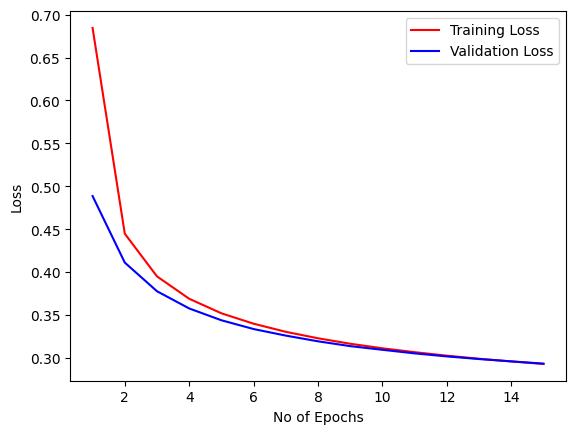

In [3]:
#Loss Visualization
epochs=[i for i in range(1,16)]
plt.plot(epochs,load_history['loss'],color='red',label='Training Loss')
plt.plot(epochs,load_history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel("No of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show

Model Evaluation

In [8]:
from tensorflow.keras.models import load_model
model=load_model("Trained_Eye_Disease_Model.h5")

ValueError: Unknown metric function: Addons>F1Score. Please ensure this object is passed to the `custom_objects` argument. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

In [9]:
pip install tensorflow-addons


Note: you may need to restart the kernel to use updated packages.


In [10]:
from tensorflow.keras.models import load_model
import tensorflow_addons as tfa

model = load_model(
    "Trained_Eye_Disease_Model.h5",
    custom_objects={"F1Score": tfa.metrics.F1Score}
)


c:\Users\anusk\anaconda3\envs\ml_env\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\anusk\anaconda3\envs\ml_env\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If 

In [11]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3small (Functiona  (None, 576)              939120    
 l)                                                              
                                                                 
 dense_2 (Dense)             (None, 4)                 2308      
                                                                 
Total params: 941,428
Trainable params: 2,308
Non-trainable params: 939,120
_________________________________________________________________


In [24]:
test_set=image_dataset_from_directory(
    "./test",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
)  

Found 10933 files belonging to 4 classes.


In [25]:
test_loss,test_acc,f1_score=model.evaluate(test_set)

342/342 [==============================] - 84s 245ms/step - loss: 0.3070 - accuracy: 0.8931 - f1_score: 0.7938


In [26]:
test_loss,test_acc,f1_score

(0.30704015493392944, 0.8930760025978088, 0.7938335537910461)

In [27]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
y_true=tf.argmax(true_categories,axis=1)

In [28]:
true_categories

<tf.Tensor: shape=(10933, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)>

In [29]:
y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [30]:
predicted_categories=model.predict(test_set)
predicted_categories

342/342 [==============================] - 83s 242ms/step


array([[9.97714281e-01, 1.86810596e-03, 4.17620002e-04, 7.95508086e-08],
       [9.95106936e-01, 3.61491251e-03, 1.27671380e-03, 1.35834910e-06],
       [8.04029047e-01, 6.59099082e-03, 1.86700180e-01, 2.67977221e-03],
       ...,
       [2.19778083e-02, 2.88691223e-02, 1.21040314e-01, 8.28112721e-01],
       [1.67595095e-03, 3.53242159e-02, 2.37175301e-02, 9.39282298e-01],
       [2.91284174e-03, 5.28440671e-03, 8.97904485e-03, 9.82823610e-01]],
      dtype=float32)

In [31]:
y_pred=tf.argmax(predicted_categories,axis=1)

In [32]:
y_pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

1.Classification Report

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      3746
           1       0.88      0.75      0.81      1161
           2       0.67      0.41      0.51       887
           3       0.91      0.98      0.94      5139

    accuracy                           0.89     10933
   macro avg       0.84      0.77      0.79     10933
weighted avg       0.89      0.89      0.89     10933



2.Confusion Metrics

In [36]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_true,y_pred)
cm

array([[3527,   62,  112,   45],
       [  89,  865,   22,  185],
       [ 265,   20,  361,  241],
       [  46,   41,   41, 5011]], dtype=int64)

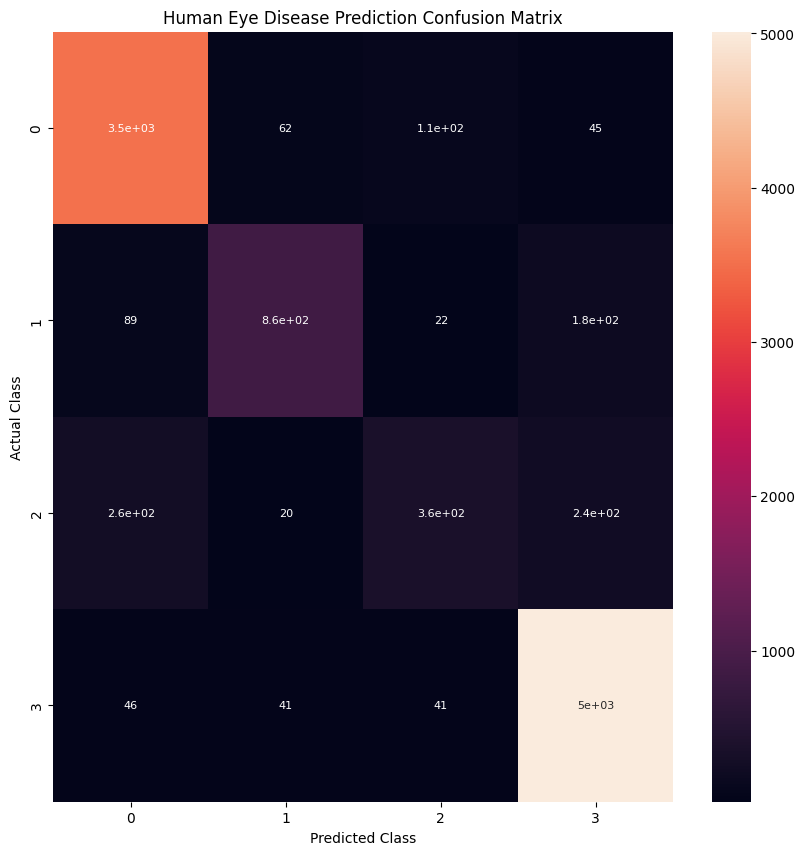

In [37]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix")
plt.show()